# Self-consistent exact-exchange optimized effective potential calculations

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Author:** Egor Trushin  
**Date created:**  08/04/2024  
**Last modified:**  17/07/2025

## 1. Introduction

In this tutorial, I will present examples of self-consistent exact-exhange (SCEXX) optimized effective potential (OEP) calculations using Molpro. These examples are intended to illustrate the main functionality and post-processing of calculations, such as plotting of resulting exchange potentials, accessing eigenvalues, etc. The tutorial is written in Jupyter Notebook. Therefore, I will use Python as a high-level programming language for preparing input files and processing of outputs.  
This tutorial complements the documentation of the SCEXX code in the Molpro manual, which I recommend you read first. I do not describe all possible input options and/or keywords, but concentrate on practical examples.

---

The approach used in the present implementation of the EXX-OEP code was introduced in
> A. Görling. New KS Method for Molecules Based on an Exchange Charge Density Generating the Exact Local KS Exchange Potential - Phys. Rev. Lett. 83, 5459 (1999). [link](https://doi.org/10.1103/PhysRevLett.83.5459)

The original implementation in Molpro was described in

> A. Heßelmann, A.W. Götz, F. Della Sala, A. Görling. Numerically stable optimized effective potential method with balanced Gaussian basis sets - J. Chem. Phys. 127, 054102 (2007). [link](https://doi.org/10.1063/1.2751159)

The current implementation with new basis set preprocessing for OEP basis set and options to symmetrize EXX-OEP in real, spin or both real and spin space is described in the following publications:

> E. Trushin, A. Görling. Numerically stable optimized effective potential method with standard Gaussian basis sets - J. Chem. Phys. 155 (2021) 054109. [link](https://doi.org/10.1063/5.0056431)  
> E. Trushin, A. Görling. Avoiding spin contamination and spatial symmetry breaking by exact-exchange-only optimized-effective-potential methods within the symmetrized Kohn-Sham framework - J. Chem. Phys. 159 (2023) 244109. [link](https://doi.org/10.1063/5.0171546)

---

<div class="alert alert-block alert-info"> <b>Important:</b> Read carefully the information below about the selection of basis sets and the thr_fai_oep parameter. </div>

SCEXX calculations requires to specify two basis sets, namely orbital and OEP basis sets. If density fitting is employed, the corresponding basis sets have to be also specified. The orbital basis set is the primary basis set for e.g. the representation of orbitals and the calculation of energy contributions. The OEP basis set is the auxiliary basis set for representing e.g. the exchange potential. 
Gaussian basis set OEP methods for a long time suffered from numerical instabilities resulting from problems in balancing the orbital basis sets with the auxiliary basis sets.
Present implementation of EXX-OEP in Molpro use a preprocessing of the auxiliary basis set that enables such balancing in an automatic fashion for standard Gaussian basis sets.
The preprocessing step removes linear combinations of auxiliary basis functions that couple poorly to products of occupied times unoccupied Kohn-Sham orbitals. It involves the threshold `thr_fai_oep`, which determines how many linear combinations of auxiliary basis functions are removed and varies with respect to the size of the orbital basis set used. This scheme was tested using Dunning correlation consistent basis sets aug-cc-pwCVXZ (X = T, Q, 5) and recommended thresholds are

| Orbital basis set | **thr_fai_oep** |
| :----: | :----: |
| aug-cc-pwCVTZ  |  5e-2   |
| aug-cc-pwCVQZ  | 1.7e-2  |
| aug-cc-pwCV5Z  |  5e-3   |

These thresholds are also expected to work for orbital basis sets without augmentation cc-pwCVXZ (X = T, Q, 5) and without core-polarization functions aug-cc-pVXZ (X = T, Q, 5).

As an auxiliary basis set (OEP), the aug-cc-pVXZ/mp2fit (X=T,Q,5) family of basis sets is recommended. In particular, it is recommended to use the aug-cc-pVDZ/mp2fit auxiliary basis sets for atoms up to neon and the aug-cc-pVTZ/mp2fit auxiliary basis sets for heavier atoms.

Def2 basis sets of Ahlrichs family of similar quality also might work, but were not tested extensively in practice.

---

There are two drivers in Molpro to perform EXX-OEP: `SCEXX` and `USCEXX`, for calculation of closed-shell systems and open-shell systems, respectively.

---

Let's start with the import of the required libraries.

In [1]:
# Standard libraries
import os
import numpy as np

# Imports for plotting
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.figsize"] = (5, 4)

The examples in this tutorial are designed to avoid computationally demanding calculations. I use my laptop for all the calculations.  
We can check information about my CPUs.

In [2]:
!lscpu | head -n 12

Architecture:                         x86_64
CPU op-mode(s):                       32-bit, 64-bit
Address sizes:                        48 bits physical, 48 bits virtual
Byte Order:                           Little Endian
CPU(s):                               16
On-line CPU(s) list:                  0-15
Vendor ID:                            AuthenticAMD
Model name:                           AMD Ryzen 9 5900HX with Radeon Graphics
CPU family:                           25
Model:                                80
Thread(s) per core:                   2
Core(s) per socket:                   8


I have Molpro in the directory `/home/trushin/Molpro/molpro`, and I am going to run it with the options `-m 2000 --no-xml-output`. I will store this in a variable for future use.

In [3]:
MOLPRO = "OMP_THREAD_LIMIT=16 /home/trushin/Molpro/molpro/bin/molpro -m 2000 --no-xml-output"

For the future, I will save the directory where this Jupyter Notebook is located.

In [4]:
NOTEBOOK_DIR = os.getcwd()

## 2. Calculations for closed-shell systems

### 2.1 CO molecule

We start with the SCEXX calculation of the closed-shell molecule, CO. We will plot the resulting exchange potentials along the bond axis, including its reference and reminder parts. 
Let's create the directory for this calculation and then go to that directory.

In [5]:
os.makedirs("Tutorials/SCEXX/co", exist_ok=True)
os.chdir("Tutorials/SCEXX/co/")

Now we write input in file co.in

In [6]:
%%writefile co.in
gdirect ! integral-direct mode

basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit
}

symmetry,nosym ! SCEXX does not use symmetry

angstrom
geometry={
2

C        0.000000    0.000000   -0.646514
O        0.000000    0.000000    0.484886
}

df-hf,maxit=0,df_basis=dfit ! HF calculation with 0 iteration
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;scexx,thr_fai_oep=1.7d-2,plot_z=1 ! SCEXX calculation

Writing co.in


Let's run Molpro calculation.

In [7]:
_ = os.system(f"{MOLPRO} < co.in > co.out") # run calculation

At the end there is the file `vx-final.z` with reference $v_x^{ref}$, rest $v_x^{rest}$ and full $v_x$ exchange potentials.  
I prepared function to parse data from data files with these potentials.

In [8]:
def load_potential(potfile):
    """Read data from potential-file.

    Args:
      potfile: Path to file with potential data.

    Returns:
      x: x coordinate.
      y: y coordinate.
      z: z coordinate.
      coord: coordinate on path.
      vref: reference potential.
      vrest: rest potential.
      v: full potential.
    """
    x, y, z, coord = list(), list(), list(), list()
    vref, vrest, v = list(), list(), list()
    for line in open(potfile):
        aux = line.split()
        x.append(float(aux[1]))
        y.append(float(aux[2]))
        z.append(float(aux[3]))
        coord.append(float(aux[4]))
        vref.append(float(aux[6]))
        vrest.append(float(aux[7]))
        v.append(float(aux[8]))
    x, y, z, coord = np.array(x), np.array(y), np.array(z), np.array(coord)
    vref, vrest, v = np.array(vref), np.array(vrest), np.array(v)
    return x, y, z, coord, vref, vrest, v

Let's parse the file and plot the potentials.

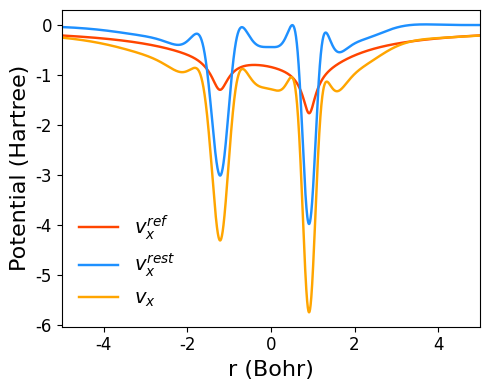

In [9]:
_, _, _, coord, vxref, vxrest, vx = load_potential('vx-final.z')

plt.plot(coord, vxref, color='orangered', label='$v_{x}^{ref}$')
plt.plot(coord, vxrest, color='dodgerblue', label='$v_{x}^{rest}$')
plt.plot(coord, vx, color='orange', label='$v_x$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

I also prepared a function to parse the resulting eigenvalues from the output file.

In [10]:
def parse_eigs(outfile):
    """Parse eigenvalues from output.

    Args:
      outfile: Path to output file.

    Returns:
      eigs: List with eigenvalues.
    """
    eigs = []
    l_parse = False
    for line in open(outfile):
        if l_parse:
            for j in line.split()[2:]:
                eigs_aux.append(float(j))
        if "SCEXX eigenvalues" in line:
            l_parse = True
            eigs_aux=[]
        if len(line.split()) == 0 and l_parse:
            l_parse = False
            eigs.append(eigs_aux)

    return eigs

Let's parse eigenvalues

In [11]:
eigs = parse_eigs("co.out")

We also need a function for a nice printout of the eigenvalues.

In [12]:
# Function to make text in bold
def bold_text(text): return "\033[1m" + text + "\033[0m"

def print_eigs(eigs, no, nmax):
    """Function to print eigenvalues for closed-shell system.
    
    Args:
      eig: List with eigenvalues.
      na: Number of occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    for i in range(nmax):
        eig = f"{eigs[i]:7.3f}"
        if i+1 <= no:
            eig = bold_text(eig)
        print(f"{i+1:2}   {eig}")

Eigenvalues are:

In [13]:
print_eigs(eigs[0], 7, 10)

 1   -18.989
 2   -10.172
 3    -1.256
 4    -0.685
 5    -0.588
 6    -0.588
 7    -0.481
 8    -0.198
 9    -0.198
10    -0.115


Eigenvalues corresponding to occupied orbitals are printed in bold.

We can also access the resulting total energy:

In [14]:
!grep "SCEXX Total energy" co.out

 !SCEXX Total energy                 -112.782858317140


### 2.2 CO molecule with HOMO condition

We can enforce an additional exact condition for the exchange potential, the so-called HOMO condition:
$$<\varphi_{HOMO}|v_x|\varphi_{HOMO}> = <\varphi_{HOMO}|\hat{v}_x^{NL}|\varphi_{HOMO}>$$
where $v_x$ is local exchange potential, $\hat{v}_x^{NL}$ is non-local exchange operator, and $\varphi_{HOMO}$ is is the HOMO of the Kohn-Sham system.  
Enforcing this condition typically leads to EXX HOMO energy close to Hartree-Fock HOMO energy.

In [15]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/SCEXX/co_homo", exist_ok=True)
os.chdir("Tutorials/SCEXX/co_homo/")

In [16]:
%%writefile co.in
gdirect ! integral-direct mode

basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit
}

symmetry,nosym ! SCEXX does not use symmetry

angstrom
geometry={
2

C        0.000000    0.000000   -0.646514
O        0.000000    0.000000    0.484886
}

df-hf,maxit=0,df_basis=dfit ! HF calculation with 0 iteration
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;scexx,thr_fai_oep=1.7d-2,plot_z=1,homo=1 ! SCEXX calculation

Writing co.in


In [17]:
_ = os.system(f"{MOLPRO} < co.in > co.out") # run calculation

In [18]:
eigs = parse_eigs("co.out")
print_eigs(eigs[0], 7, 10)

 1   -19.069
 2   -10.242
 3    -1.330
 4    -0.759
 5    -0.663
 6    -0.663
 7    -0.554
 8    -0.270
 9    -0.270
10    -0.154


As might be seen, the HOMO energy is shifted as well as other eigenvalues.

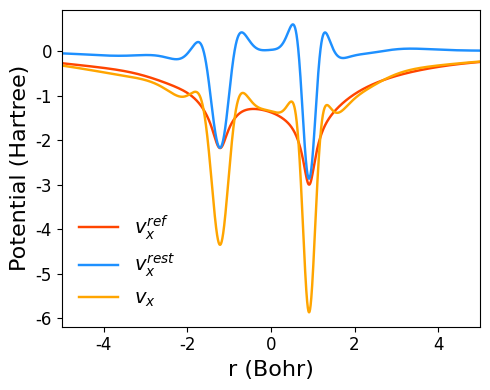

In [19]:
_, _, _, coord, vxref, vxrest, vx = load_potential('vx-final.z')

plt.plot(coord, vxref, color='orangered', label='$v_{x}^{ref}$')
plt.plot(coord, vxrest, color='dodgerblue', label='$v_{x}^{rest}$')
plt.plot(coord, vx, color='orange', label='$v_x$')

plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
!grep "SCEXX Total energy" co.out

 !SCEXX Total energy                 -112.783034057158


## 3. Calculations for open-shell systems

### 3.1 Spin-unrestricted calculation for C atom
A common way to perform Kohn-Sham (KS) calculations for open-shell systems is based on the spin-unrestricted KS method, which uses two different sets of spatial orbitals for $\alpha$ and $\beta$ electrons. This leads to two different effective KS potentials for the $\alpha$- and $\beta$-electrons.

In [21]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/SCEXX/c", exist_ok=True)
os.chdir("Tutorials/SCEXX/c/")

In [22]:
%%writefile c.in
gdirect ! integral-direct mode

basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit
}

symmetry,nosym ! USCEXX does not use symmetry

angstrom
geometry={
1

C        0.000000    0.000000   -0.646514
}

spin=2

df-uhf,maxit=0,df_basis=dfit ! HF calculation with 0 iteration
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;uscexx,thr_fai_oep=1.7d-2,plot_x=1,plot_y=1,plot_z=1,vhoep=1 ! USCEXX calculation

Writing c.in


In [23]:
_ = os.system(f"{MOLPRO} < c.in > c.out") # run calculation

In [24]:
def print_eigs_os(eiga, eigb, na, nb, nmax):
    """Function to print eigenvalues for open-shell systems.
    
    Args:
      eiga: List with alpha eigenvalues.
      eigb: List with beta eigenvalues.
      na: Number of alpha occupied orbitals.
      nb: Number of beta occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    for i in range(nmax):
        ea = f"{eiga[i]:7.3f}"
        eb = f"{eigb[i]:7.3f}"
        if i+1 <= na: 
            ea = bold_text(ea)
        if i+1 <= nb:
            eb = bold_text(eb)            
        if i+1 <= nmax:
            print(f"{i+1:2}   {ea}  {eb}")

In [25]:
eigs = parse_eigs("c.out")
print_eigs_os(eigs[0], eigs[1], 4, 2, 7)

 1   -10.231  -10.314
 2    -0.723   -0.586
 3    -0.416   -0.321
 4    -0.416   -0.263
 5    -0.367   -0.263
 6    -0.117   -0.107
 7    -0.080   -0.078


The electron configuration of C in its ground state is $1s^22s^22p^2$. There are four $\alpha$ occupied orbitals and two $\beta$ occupied orbital. Due to spin symmetry breaking, there are two spin channels with spatially different $\alpha$ and $\beta$ orbitals with different energies. Orbital energies for $\alpha$ and $\beta$ spin channels differ, reflecting spin symmetry breaking, whereas they are the same in a real electronic system. Furthermore, the energies of the orbitals in the $p$-shell in both spin channels do not exhibit a three-fold degeneracy, but split into a non-degenerate and a doubly degenerate level reflecting a cylindrical instead of spherical space symmetry. This is manifistation of space symmetry breaking.

Spin symmetry breaking leads to different exchange potentials for $\alpha$ and $\beta$ spin channels. Exchange potential also reflects space symmetry breaking - in $x$-direction it differs from $y$ and $z$ directions.  

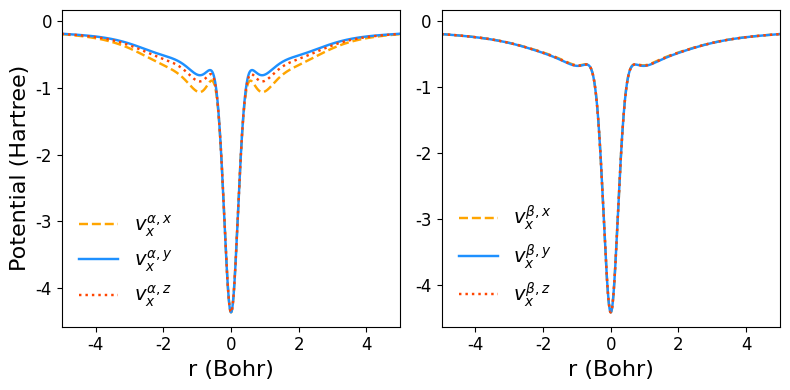

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

_, _, _, coord, _, _, vxa = load_potential('vxa-final.x')
axs[0].plot(coord, vxa, '--', color='orange', label=r'$v_{x}^{\alpha,x}$')
_, _, _, coord, _, _, vxa = load_potential('vxa-final.y')
axs[0].plot(coord, vxa, '-', color='dodgerblue', label=r'$v_{x}^{\alpha,y}$')
_, _, _, coord, _, _, vxa = load_potential('vxa-final.z')
axs[0].plot(coord, vxa, ':', color='orangered', label=r'$v_{x}^{\alpha,z}$')
axs[0].set_ylabel('Potential (Hartree)', fontsize=16)
axs[0].set_xlabel('r (Bohr)', fontsize=16)
axs[0].set_xlim(-5, 5)
axs[0].legend(frameon=False, fontsize=14)

_, _, _, coord, _, _, vxb = load_potential('vxb-final.x')
axs[1].plot(coord, vxb, '--', color='orange', label=r'$v_{x}^{\beta,x}$')
_, _, _, coord, _, _, vxb = load_potential('vxb-final.y')
axs[1].plot(coord, vxb, '-', color='dodgerblue', label=r'$v_{x}^{\beta,y}$')
_, _, _, coord, _, _, vxb = load_potential('vxb-final.z')
axs[1].plot(coord, vxb, ':', color='orangered', label=r'$v_{x}^{\beta,z}$')
axs[1].set_xlabel('r (Bohr)', fontsize=16)
axs[1].set_xlim(-5, 5)
axs[1].legend(frameon=False, fontsize=14)

plt.tight_layout()
plt.show()

Let's zoom in to see space symmetry breaking for $\beta$ spin.

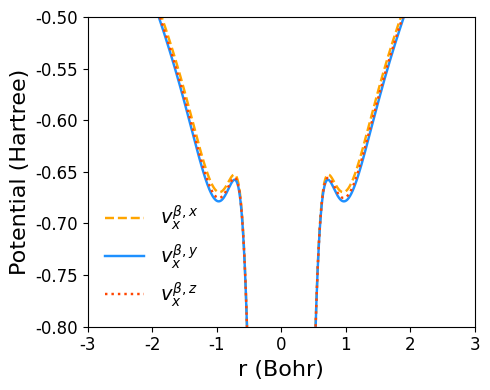

In [27]:
_, _, _, coord, _, _, vxb = load_potential('vxb-final.x')
plt.plot(coord, vxb, '--', color='orange', label=r'$v_{x}^{\beta,x}$')
_, _, _, coord, _, _, vxb = load_potential('vxb-final.y')
plt.plot(coord, vxb, '-', color='dodgerblue', label=r'$v_{x}^{\beta,y}$')
_, _, _, coord, _, _, vxb = load_potential('vxb-final.z')
plt.plot(coord, vxb, ':', color='orangered', label=r'$v_{x}^{\beta,z}$')
plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xlim(-3, 3)
plt.ylim(-0.8, -0.5)
plt.legend(frameon=False, fontsize=14)

plt.tight_layout()
plt.show()

### 3.2 Space-symmetrized calculation for C atom

In [28]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/SCEXX/c_spacesym", exist_ok=True)
os.chdir("Tutorials/SCEXX/c_spacesym/")

In [29]:
%%writefile c.in
gdirect ! integral-direct mode

basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit
}

symmetry,nosym ! USCEXX does not use symmetry

angstrom
geometry={
1

C        0.000000    0.000000   -0.646514
}

spin=2

df-uhf,maxit=0,df_basis=dfit ! HF calculation with 0 iteration
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;uscexx,thr_fai_oep=1.7d-2,plot_x=1,plot_y=1,plot_z=1,space_sym=1 ! USCEXX calculation

Writing c.in


In [30]:
_ = os.system(f"{MOLPRO} < c.in > c.out") # run calculation

In [31]:
eigs = parse_eigs("c.out")
print_eigs_os(eigs[0], eigs[1], 4, 2, 7)

 1   -10.244  -10.308
 2    -0.746   -0.581
 3    -0.422   -0.279
 4    -0.422   -0.279
 5    -0.422   -0.279
 6    -0.119   -0.106
 7    -0.081   -0.071


As might be seen, the spherical symmetry of real electronic system is restored and the orbitals in the $p$-shell are three-fold degenerate. However, the symmetry breaking in spin space remains and the orbitals in the $\alpha$ and $\beta$ spin channels and their eigenvalues are different.

Now resulting exchange potentials in both spin channels are spherical.

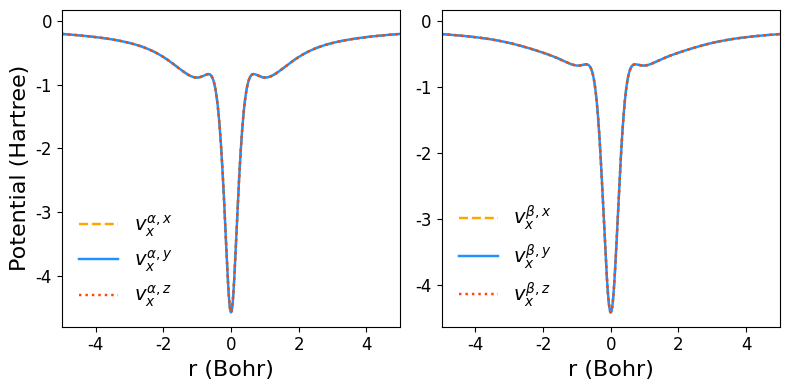

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

_, _, _, coord, _, _, vxa = load_potential('vxa-final.x')
axs[0].plot(coord, vxa, '--', color='orange', label=r'$v_{x}^{\alpha,x}$')
_, _, _, coord, _, _, vxa = load_potential('vxa-final.y')
axs[0].plot(coord, vxa, '-', color='dodgerblue', label=r'$v_{x}^{\alpha,y}$')
_, _, _, coord, _, _, vxa = load_potential('vxa-final.z')
axs[0].plot(coord, vxa, ':', color='orangered', label=r'$v_{x}^{\alpha,z}$')
axs[0].set_ylabel('Potential (Hartree)', fontsize=16)
axs[0].set_xlabel('r (Bohr)', fontsize=16)
axs[0].set_xlim(-5, 5)
axs[0].legend(frameon=False, fontsize=14)

_, _, _, coord, _, _, vxb = load_potential('vxb-final.x')
axs[1].plot(coord, vxb, '--', color='orange', label=r'$v_{x}^{\beta,x}$')
_, _, _, coord, _, _, vxb = load_potential('vxb-final.y')
axs[1].plot(coord, vxb, '-', color='dodgerblue', label=r'$v_{x}^{\beta,y}$')
_, _, _, coord, _, _, vxb = load_potential('vxb-final.z')
axs[1].plot(coord, vxb, ':', color='orangered', label=r'$v_{x}^{\beta,z}$')
axs[1].set_xlabel('r (Bohr)', fontsize=16)
axs[1].set_xlim(-5, 5)
axs[1].legend(frameon=False, fontsize=14)

plt.tight_layout()
plt.show()

### 3.3 Spin-restricted calculation for C atom

An alternative approach to the spin-unrestricted KS method is to use one set of spatial orbitals for electrons of both spins. This approach is often referred to as the spin-restricted KS method for open-shell systems. 

In [33]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/SCEXX/c_spinsym", exist_ok=True)
os.chdir("Tutorials/SCEXX/c_spinsym/")

In [34]:
%%writefile c.in
gdirect ! integral-direct mode

basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit
}

symmetry,nosym ! USCEXX does not use symmetry

angstrom
geometry={
1

C        0.000000    0.000000   -0.646514
}

spin=2

df-uhf,maxit=0,df_basis=dfit ! HF calculation with 0 iteration
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;uscexx,thr_fai_oep=1.7d-2,plot_x=1,plot_y=1,plot_z=1,vhoep=1,spin_sym=1 ! USCEXX calculation

Writing c.in


In [35]:
_ = os.system(f"{MOLPRO} < c.in > c.out") # run calculation

In [36]:
eigs = parse_eigs("c.out")
print_eigs_os(eigs[0], eigs[1], 4, 2, 7)

 1   -10.307  -10.307
 2    -0.685   -0.685
 3    -0.369   -0.369
 4    -0.369   -0.369
 5    -0.362   -0.362
 6    -0.116   -0.116
 7    -0.081   -0.081


In contrast to the spin-unrestricted case, the spin-restricted calculation does not exhibit spin symmetry breaking leading to the same orbital energies in $\alpha$ and $\beta$ spin channels. Space symmetry breaking, however, still appears.

There is only one exchange potential that we plot.

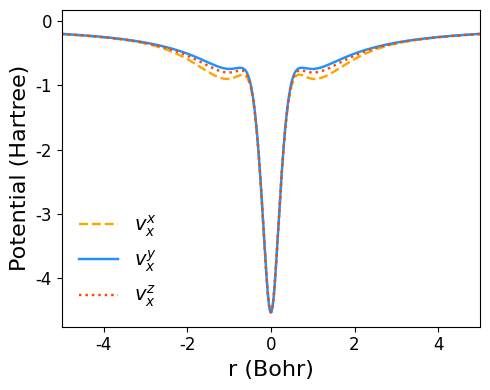

In [37]:
_, _, _, coord, _, _, vxa = load_potential('vx-final.x')
plt.plot(coord, vxa, '--', color='orange', label=r'$v_{x}^x$')
_, _, _, coord, _, _, vxa = load_potential('vx-final.y')
plt.plot(coord, vxa, '-', color='dodgerblue', label=r'$v_{x}^y$')
_, _, _, coord, _, _, vxa = load_potential('vx-final.z')
plt.plot(coord, vxa, ':', color='orangered', label=r'$v_{x}^z$')
plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=14)

plt.tight_layout()
plt.show()

### 3.4 Fully-symmetrized calculation for C atom

To restore full symmetry of real electronic system, we can use spin-restricted, i.e. spin-symmetrized, EXX method with space-symmetrization.

In [38]:
os.chdir(NOTEBOOK_DIR)
os.makedirs("Tutorials/SCEXX/c_fullsym", exist_ok=True)
os.chdir("Tutorials/SCEXX/c_fullsym/")

In [39]:
%%writefile c.in
gdirect ! integral-direct mode

basis={
default,aug-cc-pwCVQZ ! orbital basis
set,oep;default,aug-cc-pVDZ/mp2fit ! OEP basis
set,dfit;default,aug-cc-pwCV5Z/mp2fit
}

symmetry,nosym ! USCEXX does not use symmetry

angstrom
geometry={
1

C        0.000000    0.000000   -0.646514
}

spin=2

df-uhf,maxit=0,df_basis=dfit ! HF calculation with 0 iteration
{cfit,basis_coul=dfit,basis_exch=dfit}

acfd;uscexx,thr_fai_oep=1.7d-2,plot_x=1,plot_y=1,plot_z=1,space_sym=1,spin_sym=1 ! USCEXX calculation

Writing c.in


In [40]:
_ = os.system(f"{MOLPRO} < c.in > c.out") # run calculation

In [41]:
eigs = parse_eigs("c.out")
print_eigs_os(eigs[0], eigs[1], 4, 2, 7)

 1   -10.321  -10.321
 2    -0.700   -0.700
 3    -0.381   -0.381
 4    -0.381   -0.381
 5    -0.381   -0.381
 6    -0.118   -0.118
 7    -0.081   -0.081


The full symmetry of the real electronic system is restored. The orbitals in the $p$-shell exhibit three-fold degeneracy and the same orbitals result for the two spin channels.

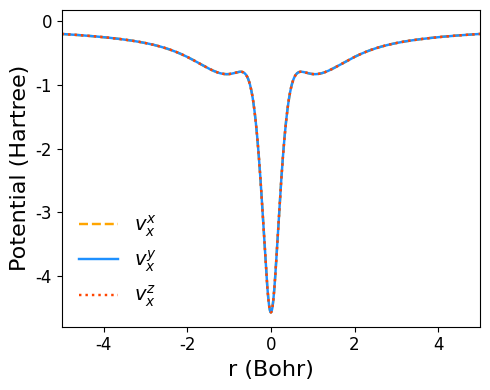

In [42]:
_, _, _, coord, _, _, vxa = load_potential('vx-final.x')
plt.plot(coord, vxa, '--', color='orange', label=r'$v_{x}^x$')
_, _, _, coord, _, _, vxa = load_potential('vx-final.y')
plt.plot(coord, vxa, '-', color='dodgerblue', label=r'$v_{x}^y$')
_, _, _, coord, _, _, vxa = load_potential('vx-final.z')
plt.plot(coord, vxa, ':', color='orangered', label=r'$v_{x}^z$')
plt.ylabel('Potential (Hartree)', fontsize=16)
plt.xlabel('r (Bohr)', fontsize=16)
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=14)

plt.tight_layout()
plt.show()

Finally, we can verify that effect of symmetrizations make EXX total energy higher:

In [43]:
os.chdir(NOTEBOOK_DIR)

Total energy from spin-nrestricted, i.e. non-symmetrized, calculation:

In [44]:
!grep "SCEXX Total energy" Tutorials/SCEXX/c/c.out

 !USCEXX Total energy                 -37.691557644612


Total energy from spin-unrestricted space-symmetrized calculation:

In [45]:
!grep "SCEXX Total energy" Tutorials/SCEXX/c_spacesym/c.out

 !USCEXX Total energy                 -37.688391154009


Total energy from spin-restricted, i.e. spin-symmetrized, calculation:

In [46]:
!grep "SCEXX Total energy" Tutorials/SCEXX/c_spinsym/c.out

 !USCEXX Total energy                 -37.685805645074


Total energy from spin-restricted space-symmetrizatrized, i.e. fully-symmetrized, calculation:

In [47]:
!grep "SCEXX Total energy" Tutorials/SCEXX/c_fullsym/c.out

 !USCEXX Total energy                 -37.685640888954


## 4. Concluding remarks
In this tutorial, we explored self-consistent exact-exchange calculations using Molpro. We considered calculations for closed- and open-shell systems.

For open-shell systems, in addition to the standard spin-unrestricted EXX method, we looked at the spin-restricted EXX mehod, which preserves the correct spin symmetry of a real electronic system. For both spin-unrestricted and spin-restricted EXX methods for open-shell systems, we also performed calculations with additional space-symmetrization, which forces the KS system to have the correct spatial symmetry of a real electronic system.

We considered an option to enforce an additional exact condition for the exchange potential, the so-called HOMO condition.

As a post-processing of calculations, we accessed and printed orbital energies and explored how to plot the resulting exchange potential and its individual contributions.

---

[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/EgorTrushin/Molpro_Tutorials/issues)  For any questions, typos, or bugs that you found, please raise an issue on GitHub.  
[![Star the repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20the%20Repository&color=yellow)](https://github.com/EgorTrushin/Molpro_Tutorials/)  If you found this tutorial helpful, consider ⭐-ing the repository.